<a href="https://colab.research.google.com/github/TAMIDSpiyalong/Advanced-Concepts-in-Machine-Learning-for-Energy/blob/main/Lecture_5d_prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Forecasting Model - Facebook Prophet
Prophet is a procedure for forecasting time series data based on an additive model where non-linear trends are fit with yearly, weekly, and daily seasonality, plus holiday effects. It works best with time series that have strong seasonal effects and several seasons of historical data. Prophet is robust to missing data and shifts in the trend, and typically handles outliers well.

## Background
The Prophet forecasting model is based on the following formula
$$y(t) = g(t) + s(t) + h(t) + \epsilon_t,$$
where $y(t)$ are the observations at time $t, t=1,\dots, T$ (training data). $g(t)$, $s(t)$, $h(t)$ are the **trend**, **seasonality**, **holiday** components respectively.

The trends are modeled by a logistic (S-shape trend) function or a piecewise linear function. The seasonalities are modeled by the Fourier series. The holidays are modeled by the indicators. The illustration of the detailed model can be found in https://peerj.com/preprints/3190v2/

The forecasting procedure is: first obtain the estimating of these three components $\widehat{g}(t)$, $\widehat{s}(t)$, $\widehat{h}(t)$. At the new time point $T+1$, forecast the output value $\widehat{y}(T+1) = \widehat{g}(T+1) + \widehat{s}(T+1) + \widehat{h}(T+1)$.

Pros of Prophet:

1. Flexibility: We can easily accommodate seasonality with multiple periods and let the analyst make different assumptions about trends.
2. Not neccessary time regularly spaced
3. Fast computation
4. Easily interpretable components

In [ ]:
# install facebook prophet if it is not installed yet
#!pip install prophet

### Read Data
To utilize Facebook Prophet forecasting model, the column names must be `ds` (the data timestamps) and `y` (the numeric values) respectively.

In [ ]:
# Sample Energy consumption data of in UK.
# https://data.london.gov.uk/dataset/smartmeter-energy-use-data-in-london-households
import pandas as pd

df1 = pd.read_csv('https://raw.githubusercontent.com/jtao/AdvancedML/main/data/Energy.csv', parse_dates=["day"])

In [ ]:
df1

,day,energy_median
0,2012-04-27,0.1245
1,2012-04-28,0.0850
2,2012-04-29,0.0875
3,2012-04-30,0.0795
4,2012-05-01,0.0795
...,...,...
668,2014-02-24,0.0605
669,2014-02-25,0.0590
670,2014-02-26,0.0545
671,2014-02-27,0.0545


In [ ]:
df1.columns = ["ds","y"]  # change the column names
df1

,ds,y
0,2012-04-27,0.1245
1,2012-04-28,0.0850
2,2012-04-29,0.0875
3,2012-04-30,0.0795
4,2012-05-01,0.0795
...,...,...
668,2014-02-24,0.0605
669,2014-02-25,0.0590
670,2014-02-26,0.0545
671,2014-02-27,0.0545


### Forecasting
We then use the Prophet function to forecast the future values. To verify the forecasting model, we separate the electricity daily data into two parts. First part is the values from day 1 to day 650 as the training data, while the second part is the rest of days.

The arguments `daily_seasonality`, `yearly_seasonality`, and `weekly_seasonality` can be manually controlled based on training data. `interval_width` from 0 to 1 controls the size of forecasting confidence intervals. The higher `interval_width` is, the larger confidence interval is.

We also consider the holiday effects during forecasting, since the holidays do affect the electricity consumptions.

In [ ]:
# import Prophet
from prophet import Prophet

# model fitting and forecasting
m = Prophet(daily_seasonality = False, yearly_seasonality = True, weekly_seasonality = True,interval_width=0.8)
m.add_country_holidays(country_name='US')
m.fit(df1[1:650])
future = m.make_future_dataframe(periods=31) # future 31 time points

forecast = m.predict(future) # forecast
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

DEBUG:cmdstanpy:input tempfile: /tmp/tmpe56foa1e/eo_a6dvi.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpe56foa1e/ny95mf5g.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=24615', 'data', 'file=/tmp/tmpe56foa1e/eo_a6dvi.json', 'init=/tmp/tmpe56foa1e/ny95mf5g.json', 'output', 'file=/tmp/tmpe56foa1e/prophet_model9t1yc2xf/prophet_model-20250415153148.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:31:48 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:31:49 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
675,2014-03-04,0.054980,0.043026,0.069248
676,2014-03-05,0.054993,0.041863,0.069078
677,2014-03-06,0.054564,0.041511,0.068567
678,2014-03-07,0.053380,0.038809,0.066327
679,2014-03-08,0.053656,0.040341,0.067187


In [ ]:
m.train_holiday_names

,0
0,New Year's Day
1,New Year's Day (observed)
2,Memorial Day
3,Independence Day
4,Labor Day
5,Veterans Day
6,Veterans Day (observed)
7,Thanksgiving Day
8,Christmas Day
9,Martin Luther King Jr. Day


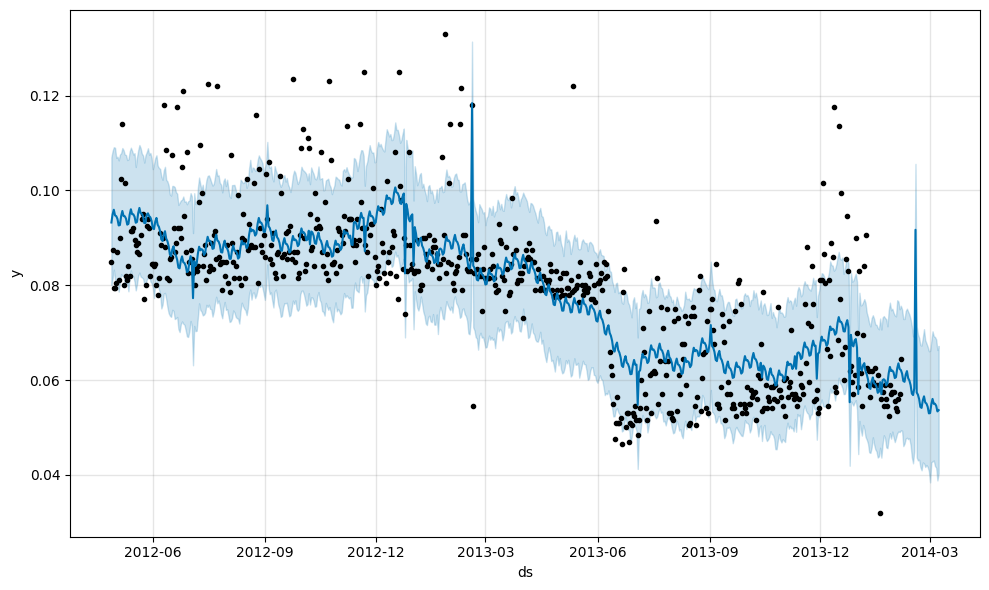

In [ ]:
# plot the model fitting and forecasting with pointwise confidence intervals.
fig1 = m.plot(forecast)

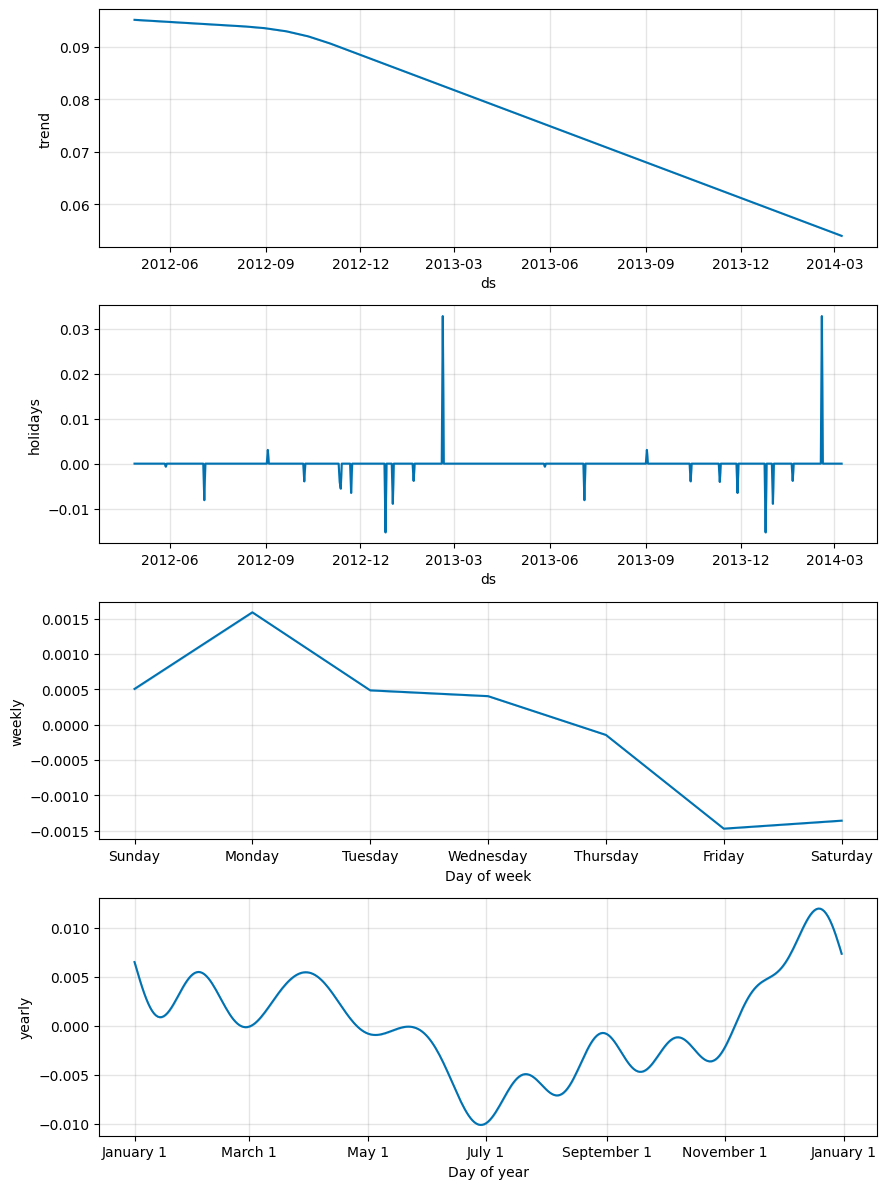

In [ ]:
# different components
fig2 = m.plot_components(forecast)

In [ ]:
# interactive plots
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(m, forecast)

## Automatic anomaly detection
We develop the `anomalydetection` function to detect the anomalies via Facebook Prophet.

The inputs are `data_train`, `data_test`, and `interval_width`, while the outputs are the labels of `normal data` or `anomalies`.

Also, we can manually control the different seasonalities in the inner function.


In [ ]:
# The automatic anomaly detection function
# inputs
# data_train: the training data consist two columns: first column 'ds' represents the timestamps;
#               second column 'y' represents the numeric values.
# data_test: the testing data with two columns similar to data_train.
# interval_width: the width of prediction interval
# outputs
# labels: the labels indicating the testing data are anomalies or not.

def anomalydetection(data_train,data_test,interval_width):
    from prophet import Prophet
    m = Prophet(daily_seasonality = False, yearly_seasonality = True, weekly_seasonality = True,interval_width=interval_width)
    m.add_country_holidays(country_name='US')
    m.fit(data_train)
    future = m.make_future_dataframe(periods=data_test.shape[0])
    forecast = m.predict(future)

    intervals = forecast[(data_train.shape[0]):(data_train.shape[0]+data_test.shape[0])][['ds','yhat_lower','yhat_upper']]

    labels = []
    for i in range(data_test.shape[0]):
        if data_test.iloc[i-1].at['y'] > intervals.iloc[i-1].at['yhat_lower'] and data_test.iloc[i-1].at['y'] < intervals.iloc[i-1].at['yhat_upper']:
            labels.append('Normal')
        else:
            labels.append('Anomaly')
    return labels

In [ ]:
anomalydetection(df1[0:650],df1[650:673],interval_width=0.95)

DEBUG:cmdstanpy:input tempfile: /tmp/tmpe56foa1e/gq9riwqa.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpe56foa1e/c3bmmnwv.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=53713', 'data', 'file=/tmp/tmpe56foa1e/gq9riwqa.json', 'init=/tmp/tmpe56foa1e/c3bmmnwv.json', 'output', 'file=/tmp/tmpe56foa1e/prophet_modeladgexx10/prophet_model-20250415153153.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:31:53 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:31:53 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


['Anomaly',
 'Normal',
 'Anomaly',
 'Normal',
 'Normal',
 'Normal',
 'Anomaly',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Anomaly',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal']